In [9]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

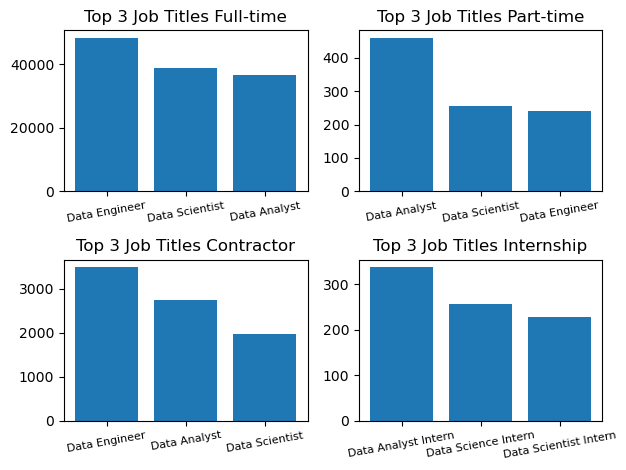

In [74]:
fig, ax = plt.subplots(2, 2)

schedules = ['Full-time', 'Part-time', 'Contractor', 'Internship']



for i, item in enumerate(schedules):

    df_indexed = (df[df['job_schedule_type'] == item]
        ['job_title'].value_counts()
        .head(3)
    )
    ax[i//2, i%2].bar(df_indexed.index, df_indexed.values)
    ax[i//2, i%2].set_title(f'Top 3 Job Titles {item}')
    ax[i//2, i%2].tick_params(axis = 'x', labelsize=8, labelrotation=10)


fig.tight_layout()

plt.show()
    




